## LassoCV from sckit-learn

The optimization problem is written as:
$$
  \min_\beta \frac{1}{2n}\|Y - X\beta\|_2^2 + \alpha \|\beta\|_1 = \frac{1}{n}\big(\min_\beta \frac{1}{2}\|Y - X\beta\|_2^2 + (\lambda := \alpha \cdot n) \|\beta\|_1\big)
$$
i.e. the scaling factor depends on the number of samples.

## Applying the 1SE Rule, Insipred by glmnet in R

Step by step breakdown:


*   In glmnet, the "1SE" refers to the standard error: $SE = \tfrac{std(MSE)}{\sqrt{folds}}$ calculated acrossthe folds for the $\alpha$ that achieves the **minimum mean MSE**.
*   The **MSE threshold** is then defined as **sum** of the **mininum mean MSE** and $SE$
*   Finally, the **1SE alpha** is the largest $\alpha$ where **mean MSE** $\le$ **MSE threshold**.



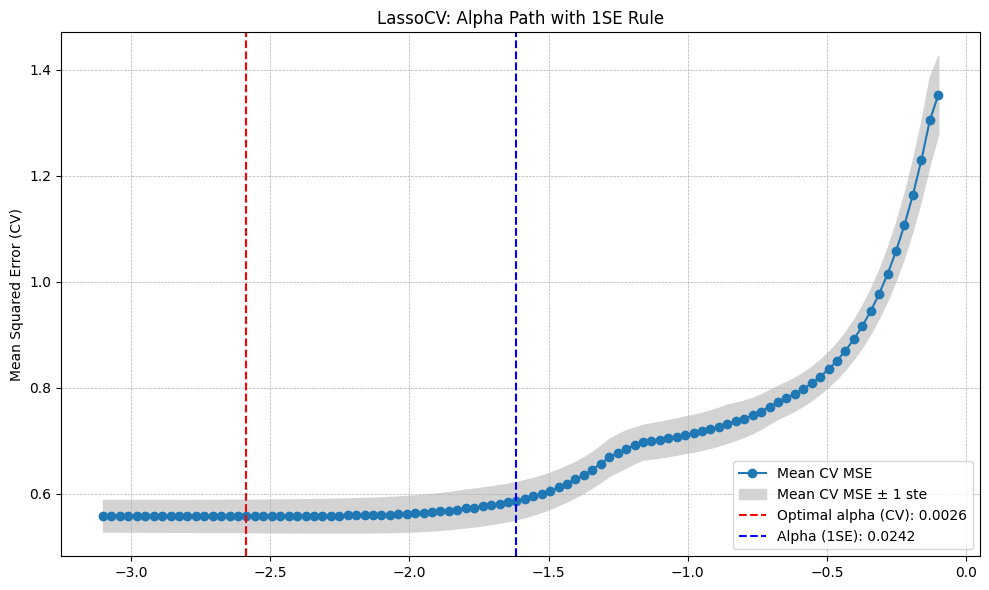

In [ ]:
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LassoCV
import matplotlib.pyplot as plt

housing = fetch_california_housing()
X, y = housing.data, housing.target
feature_names = housing.feature_names

# Standarize the data
X = (X - np.mean(X, axis=0))/np.std(X, axis=0)

n_folds = 5
lasso = LassoCV(cv=n_folds, random_state=42).fit(X, y)

# Exctarct alphas, regularization path, and MSE path
alphas, mse_path = lasso.alphas_, lasso.mse_path_

# 1SE estimate
mean_mse = np.mean(mse_path, axis=1)
ste_mse = np.std(mse_path, axis=1) / np.sqrt(n_folds)
min_mse = np.min(mean_mse)
ste_mse_at_min = ste_mse[mean_mse == min_mse][0]
alpha_1se = alphas[mean_mse <= min_mse + ste_mse_at_min][0]

# Plot the alpha path
plt.figure(figsize=(10, 6))
plt.plot(np.log10(alphas), mean_mse, label="Mean CV MSE", marker="o")
plt.fill_between(
    np.log10(alphas),
    mean_mse - ste_mse,
    mean_mse + ste_mse,
    color="lightgray",
    label="Mean CV MSE ± 1 ste",
)
plt.axvline(np.log10(lasso.alpha_), color="red", linestyle="--", label=f"Optimal alpha (CV): {lasso.alpha_:.4f}")
plt.axvline(np.log10(alpha_1se), color="blue", linestyle="--", label=f"Alpha (1SE): {alpha_1se:.4f}")
plt.xlabel(r"")
plt.ylabel("Mean Squared Error (CV)")
plt.title("LassoCV: Alpha Path with 1SE Rule")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


## The question

How does varying the regularization parameter $\lambda$ in Ridge and Lasso regression impact the trade-off between bias and variance?



*   We will work with a synthetic dateset based on a known linear relationship:
$$
  y = \beta_0 + \beta_1x_1 + \beta_2x_2 + \dots + \varepsilon
$$
with the ground trouth:
$$
  f(X) = \beta_0 + \beta_1x_1 + \beta_2x_2 + \dots
$$
and noise $\varepsilon \sim \mathcal{N}(0, \sigma^2)$.
Remember,
$$
  y = f(X) + \varepsilon
$$
Use a high-dimensional setting, (e.g., $50$ predictors) with only a few non-zero true coefficients to emphasize the effects of regularization. I stress, the $\beta_i$ coefficients should be known for this experiment and they should be mostly $0$, with only a few non-zero parameters.
*   Investigate how increasing $\lambda$ influences the model's bias, variance and MSE.
*   Explain MSE decomposition into bias and variance and irreducibe error. Read more on the MSE decomposition if you need to.

**Does the regularization lead to an optimal trade-off point where MSE is minimized? Explain why this point exists.**



## Ridge Regression

$$
  \min_\beta \|Y - X \beta\|_2^2 + \lambda\|\beta\|_2^2
$$

We have
$$
  \|Y - X\beta\|_2^2 + \|0_p - \sqrt{\lambda} I_p\beta\|_2^2 = \big\|
  \begin{bmatrix}
    Y\\
    0_p
  \end{bmatrix} -
  \begin{bmatrix}
    X\\
    \sqrt{\lambda} I_p
  \end{bmatrix}
  \beta
  \big\|_2^2.
$$
Which means that
\begin{align}
  \hat\beta
  &= \big(
    \begin{bmatrix}
      X^T & \sqrt{\lambda}I_p
    \end{bmatrix}
    \begin{bmatrix}
    X\\
    \sqrt{\lambda} I_p
  \end{bmatrix}
  \big)^{-1}
  \begin{bmatrix}
      X^T & \sqrt{\lambda}I_p
    \end{bmatrix}
    \begin{bmatrix}
    Y\\
    0_p
  \end{bmatrix}\\
  &= (X^TX + \lambda I_p)^{-1} X^TY.
\end{align}

We can derive
\begin{align}
  bias(\hat \beta)
  &= \mathbb{E}\hat \beta - \beta\\
  &= ((X^TX + \lambda I_p)^{-1}X^TX - I_p)\beta\\
  &= ((X^TX + \lambda I_p)^{-1}(X^TX + \lambda I_p - \lambda I_p) - I_p)\beta\\
  &=  -\lambda(X^T X+ \lambda I_p)^{-1}\beta
\end{align}
and
\begin{align}
  Var (\hat \beta)
  &= (X^TX + \lambda I_p)^{-1}X^TVar(Y) X(X^TX + \lambda I)^{-1}\\
  &= \sigma^2(X^TX + \lambda I_p)^{-1}X^TX(X^TX + \lambda I_p)^{-1}.
\end{align}

As $\lambda \rightarrow 0$
$$
  \hat \beta \rightarrow (X^TX)^{-1}X^TY.
$$
In this case $bias (\hat \beta) \rightarrow 0$ and $Var (\hat \beta)\rightarrow \sigma^2(X^TX)^{-1}$.

As $\lambda \rightarrow \infty$
$$
  \hat \beta \rightarrow 0.
$$
In this case $bias (\hat \beta) \rightarrow - \beta$ and $Var (\hat \beta) \rightarrow 0$.

## Squared bias decomposition for linear models

For a linear model family let $\tilde \beta$ denote the parameters of the best-fitting linear approximation to $f$ without restrictions.

Let $\mathcal{T}$ denote the train sample, independent from test sample, then we can write the average squared bias as
\begin{align}
  \mathbb{E}_{x_0}[(f(x_0) - x_0^T\mathbb{E}_{\mathcal{T}}\hat \beta)^2]
  &= \mathbb{E}_{x_0}[(f(x_0) - x_0^T\mathbb{E}_{\mathcal{T}}\hat \beta + x_0^T \tilde \beta- x_0^T \tilde\beta)(f(x_0) - x_0^T\mathbb{E}_{\mathcal{T}} \hat \beta + x_0^T \tilde \beta - x_0^T \tilde\beta)]\\
  &= \mathbb{E}_{x_0}[(f(x_{0}) - x_0^T \tilde \beta)^2] + \mathbb{E}_{x_0}[(x_0^T \tilde \beta - x_0^T\mathbb{E}_{\mathcal{T}}\hat \beta)^2].
\end{align}
The cross term
$$
  \mathbb{E}_{x_0}[(f(x_0) - x_0^T \tilde \beta)(x_0^T\tilde \beta - x_0^T \mathbb{E}_{\mathcal{T}} \hat \beta)] = (\tilde \beta - \mathbb{E}_{\mathcal{T}}\hat \beta)\mathbb{E}[x_0(f(x_0) - x_0^T\tilde \beta)]
$$
vanishes becouse the first-order optimization yields
$$
  \mathbb{E}[x_0(f(x_0) - x_0^T\tilde \beta)] = 0.
$$

For restricted linear models the second term is positive, and we trade it oﬀ
with the benefits of a reduced variance. If the decrease in variance exceeds the increase in
(squared) bias, then this is worthwhile.

In [ ]:
from sklearn.linear_model import Lasso, Ridge

# Parameters
p = 50
test_size = 800
coeffs = np.zeros(p)
coeffs[:5] = [2, -1.5, 1, 3, -2.5]

# Generate training and test sets
np.random.seed(42)
mu, Sigma = np.zeros(p), np.eye(p)

X_test = np.random.multivariate_normal(mean=mu, cov=Sigma, size=test_size)
f_test = X_test @ coeffs
y_test = f_test + np.random.normal(scale=1.0, size=test_size)

# Lambdas
n_lambdas = 20
lambdas = 10 ** np.linspace(-4, 2, n_lambdas)

# Sample settings
sample_size = 30
n_samples = 100

# Lists to collect results
lasso_mse = []
lasso_squared_bias = []
lasso_variance = []

ridge_mse = []
ridge_squared_bias = []
ridge_variance = []

# Model fitting and estimation
for lambda_val in lambdas:
  lasso_preds = []
  ridge_preds = []

  for _ in range(n_samples):
    X_train = np.random.multivariate_normal(mu, Sigma, sample_size)
    y_train = X_train @ coeffs + np.random.normal(scale=1.0, size=sample_size)

    lasso = Lasso(alpha=lambda_val, max_iter=10000)
    lasso.fit(X_train, y_train)
    lasso_preds.append(lasso.predict(X_test))

    ridge = Ridge(alpha=lambda_val)
    ridge.fit(X_train, y_train)
    ridge_preds.append(ridge.predict(X_test))

  lasso_preds = np.array(lasso_preds)
  ridge_preds = np.array(ridge_preds)

  # quantitative values calculation
  lasso_mean = np.mean(lasso_preds, axis=0)
  ridge_mean = np.mean(ridge_preds, axis=0)
  lasso_mse.append(np.mean((lasso_preds - y_test)**2))
  ridge_mse.append(np.mean((ridge_preds - y_test)**2))
  lasso_squared_bias.append(np.mean((lasso_mean - f_test)**2))
  ridge_squared_bias.append(np.mean((ridge_mean - f_test)**2))
  lasso_variance.append(np.mean((lasso_preds - lasso_mean)**2))
  ridge_variance.append(np.mean((ridge_preds - ridge_mean)**2))

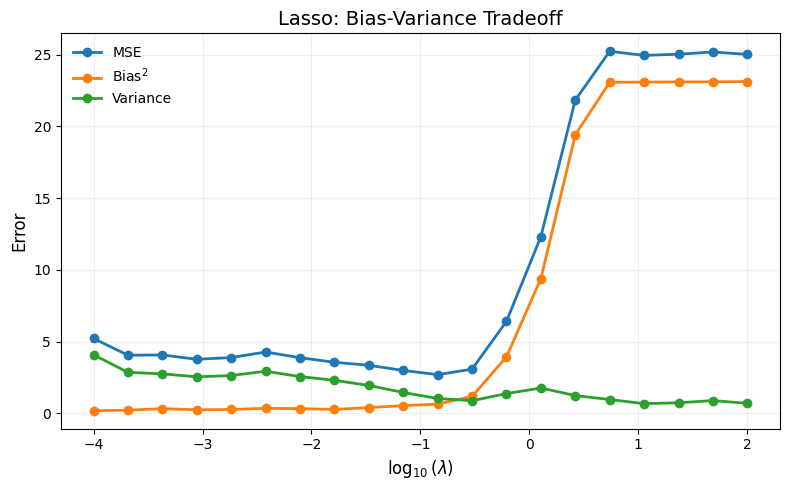

In [ ]:
# Lasso
x = np.log10(lambdas)
plt.figure(figsize=(8, 5))

plt.plot(x, lasso_mse, marker='o', linewidth=2, label='MSE')
plt.plot(x, lasso_squared_bias, marker='o', linewidth=2, label=r'Bias$^2$')
plt.plot(x, lasso_variance, marker='o', linewidth=2, label='Variance')

plt.xlabel(r'$\log_{10}(\lambda)$', fontsize=12)
plt.ylabel("Error", fontsize=12)
plt.title("Lasso: Bias-Variance Tradeoff", fontsize=14)

plt.legend(frameon=False)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


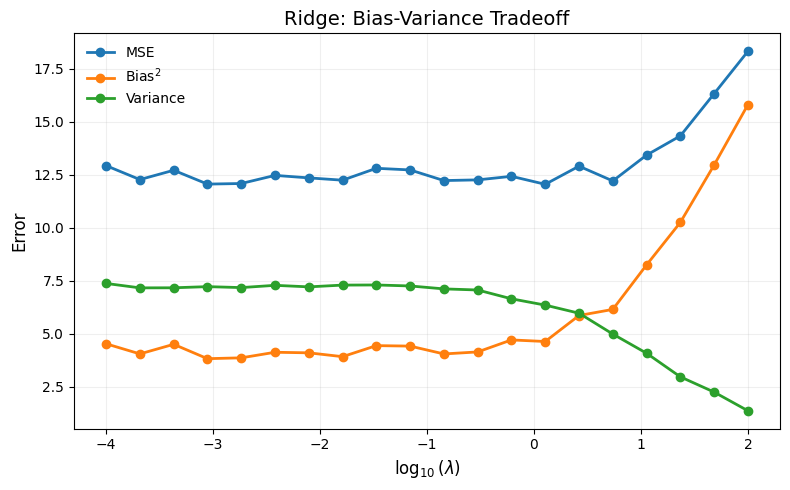

In [ ]:
# Ridge
plt.figure(figsize=(8, 5))

plt.plot(x, ridge_mse, marker='o', linewidth=2, label='MSE')
plt.plot(x, ridge_squared_bias, marker='o', linewidth=2, label=r'Bias$^2$')
plt.plot(x, ridge_variance, marker='o', linewidth=2, label='Variance')

plt.xlabel(r'$\log_{10}(\lambda)$', fontsize=12)
plt.ylabel("Error", fontsize=12)
plt.title("Ridge: Bias-Variance Tradeoff", fontsize=14)

plt.legend(frameon=False)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Ridge trades off variance and bias smoothly, keeping all variables.

Lasso can aggressively increase bias but encourages sparsity, which is useful in high-dimensional settings.